In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from IPython.display import Image,display
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.checkpoint.memory import MemorySaver
from langchain_tavily import TavilySearch
from langgraph.graph.message import add_messages


In [37]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [77]:
llm=init_chat_model(model="groq:openai/gpt-oss-120b")
tool=TavilySearch(max_results=2)
agent=llm.bind_tools([tool])

In [87]:
def tool_calling_llm(state:State):
    return {"messages":[agent.invoke(state['messages'])]}

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm',tools_condition)
builder.add_edge('tools',"tool_calling_llm")

graph=builder.compile(checkpointer =MemorySaver())

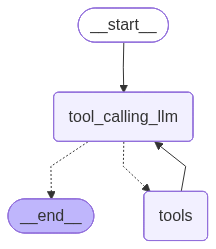

In [88]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:
response=graph.invoke({'messages':'give me recent ai news'})
response['messages'][-1].content


'**AI‑News Brief –\u202fLate\u202fMay\u202f2026 (last 48\u202fhrs)**  \n\n| Topic | Key Development | Why It Matters | Source |\n|-------|----------------|----------------|--------|\n| **AI‑generated evidence in U.S. courts** | Two recent district‑court rulings – *United States v. Heppner* (S.D.N.Y.) and *Morgan v. V2X, Inc.* (D.\u202fColo.) – set contrasting standards for how AI‑created documents are treated in discovery and privilege disputes. The Heppner case treats AI‑generated drafts as “ordinary work product,” while Morgan requires a separate privilege analysis. | Signals the start of a fragmented legal landscape; lawyers will need clear policies for AI‑assisted drafting and preservation. | Reuters, 27\u202fMay\u202f2026 |\n| **AI‑focused small‑cap rally** | Investors are chasing “inference‑infrastructure” plays. • **VIAVI** (network‑test & optical‑security) and **MaxLinear** (semiconductors) have posted triple‑digit stock gains this year after reporting strong demand from hypers

In [90]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

give me recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_30d45e14-408e-42ba-b928-d2f50300ed26)
 Call ID: fc_30d45e14-408e-42ba-b928-d2f50300ed26
  Args:
    query: latest AI news May 2026
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news May 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.instagram.com/reel/DY3BqI0PTUU", "title": "May 27 2026: AI CEOs walk back what they said perhaps ...", "content": "Generative AI could raise global GDP by 7% Effect of AI adoption on annual labor productivity growth, 10-year adoption period 300 million full-time jobs to", "score": 0.7552947, "raw_content": null}, {"url": "https://www.pbs.org/newshour/show/may-27-2026-pbs